Estimated normalization factor Z = 1.8128049541109543

Acceptance Rates:
Uniform proposal step_size = 1: 0.7127127127127127
Normal proposal sigma = 1: 0.5905905905905906


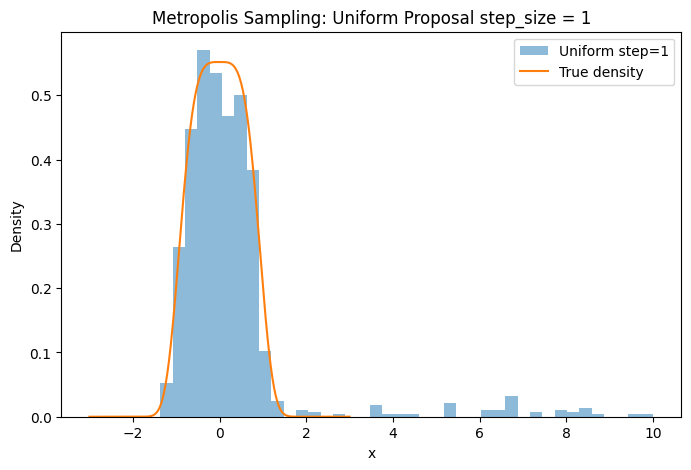

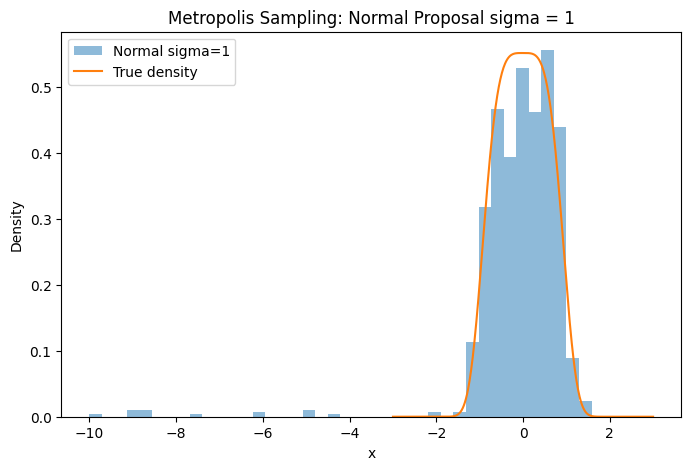

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy import integrate

# =========================
# Metropolis Algorithm
# =========================

Z =  integrate.quad(lambda x: np.exp(-x**4), -np.inf, np.inf)[0]


def target_fn(x):
    """
    Target distribution:
        pi(x) ∝ exp(-x^4)
    """
    return np.exp(-x**4) / Z


def log_target_fn(x):
    """
    Log target density. Using this in the sampler avoids numerical
    underflow from exp(-x^4) when |x| is large.
    """
    return -x**4 - np.log(Z)

print("Estimated normalization factor Z =", Z)


# =========================
# Symmetric Proposal Functions
# =========================

def uniform_proposal(x, step_size=1):
    """
    Symmetric uniform proposal:
        y ~ U[x - step_size, x + step_size]
    """
    return x + np.random.uniform(-step_size, step_size)


def normal_proposal(x, sigma=1):
    """
    Symmetric normal proposal:
        y ~ N(x, sigma^2)
    """
    return x + np.random.normal(0, sigma)



# =========================
# Metropolis Sampler
# =========================

def metropolis_sampler(num_samples, proposal_fn, initial_x=0):
    samples = [initial_x]
    x = initial_x
    accepted = 0

    for _ in range(num_samples - 1):
        x_proposal = proposal_fn(x)

        log_acceptance_ratio = log_target_fn(x_proposal) - log_target_fn(x)
        alpha = 1 if log_acceptance_ratio >= 0 else np.exp(log_acceptance_ratio)

        if np.random.rand() < alpha:
            x = x_proposal
            accepted += 1

        samples.append(x)

    acceptance_rate = accepted / (num_samples - 1)

    return np.array(samples), acceptance_rate


# =========================
# Generate Samples
# =========================

N = 1000

samples_uniform, acc_uniform = metropolis_sampler(
    N,
    lambda x: uniform_proposal(x, step_size=1),
    initial_x=10
)

samples_normal, acc_normal = metropolis_sampler(
    N,
    lambda x: normal_proposal(x, sigma=1),
    initial_x=-10
)



print("\nAcceptance Rates:")
print("Uniform proposal step_size = 1:", acc_uniform)
print("Normal proposal sigma = 1:", acc_normal)


# =========================
# Visualization
# =========================

x_vals = np.linspace(-3, 3, 500)
true_density = np.exp(-x_vals**4) / Z

plt.figure(figsize=(8, 5))
plt.hist(samples_uniform, bins=40, density=True, alpha=0.5, label="Uniform step=1")
plt.plot(x_vals, true_density, label="True density")
plt.title("Metropolis Sampling: Uniform Proposal step_size = 1")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(samples_normal, bins=40, density=True, alpha=0.5, label="Normal sigma=1")
plt.plot(x_vals, true_density, label="True density")
plt.title("Metropolis Sampling: Normal Proposal sigma = 1")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

